In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf
from scipy.special import expit
from scipy.stats import binom
from empiricaldist import Pmf, Cdf

In [2]:
def normalize(joint):
    """Normalize the joint distribution."""
    prob_data = joint.to_numpy().sum()
    joint /= prob_data
    return prob_data

def make_joint(pmf1, pmf2):
    """Make a joint distribution from two PMFs."""
    X, Y = np.meshgrid(pmf1, pmf2)
    return pd.DataFrame(X * Y, columns=pmf1.qs, index=pmf2.qs)

def make_uniform(qs, name=None, **options):
    """Make a uniform PMF."""
    pmf = Pmf(1.0, qs, **options)
    pmf.normalize()
    if name:
        pmf.index.name = name
    return pmf

# function for marginal distribution
def marginal(joint, axis):
    """Return the marginal distribution."""
    return Pmf(joint.sum(axis=axis))

def plot_contour(joint):
    '''plot a joint distribution as a contour plot.'''
    plt.contour(joint.columns, joint.index, joint, cmap='viridis')

In [3]:
o_rings = pd.read_csv('o-rings.csv')
o_rings = o_rings.dropna()
o_rings.head(5)

,Date,Temperature,Damage Incident
0,04/12/1981,66,0.0
1,11/12/1981,70,1.0
2,3/22/82,69,0.0
4,01/11/1982,68,0.0
5,04/04/1983,67,0.0


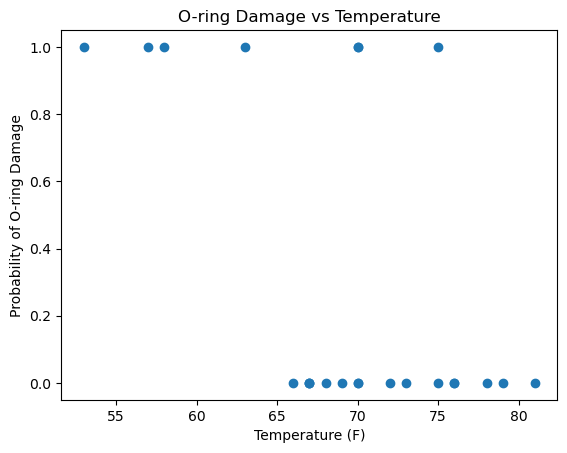

In [4]:
plt.scatter(o_rings['Temperature'], o_rings['Damage Incident'])
plt.xlabel('Temperature (F)')
plt.ylabel('Probability of O-ring Damage')
plt.title('O-ring Damage vs Temperature')
plt.show()

In [5]:
offset = o_rings['Temperature'].mean().round()
o_rings['x'] = o_rings['Temperature'] - offset
offset

np.float64(70.0)

In [6]:
o_rings['y'] = o_rings['Damage Incident']

In [7]:
formula = 'y ~ x'
results = smf.logit(formula, data=o_rings).fit()
results.params

Optimization terminated successfully.
         Current function value: 0.441635
         Iterations 6


Intercept   -1.208490
x           -0.232163
dtype: float64

In [8]:
inter = results.params['Intercept']
slope = results.params['x']
xs = np.arange(53, 83) - offset
log_odds = inter + slope * xs
odds = np.exp(log_odds)
ps = odds / (1 + odds)
ps = expit(inter + slope * xs)

### Previous was a conventional logistic regression. Following will be a Bayesian log regression.

In [9]:
qs = np.linspace(-5, 1, num=101)
prior_inter = make_uniform(qs, 'Intercept')

qs = np.linspace(-0.8, 0.1, num=101)
prior_slope = make_uniform(qs, "Slope")

In [10]:
joint = make_joint(prior_inter, prior_slope)

In [11]:
joint_Pmf = Pmf(joint.stack())
joint_Pmf.head()

-0.8  -5.00    0.000098
      -4.94    0.000098
      -4.88    0.000098
dtype: float64

In [12]:
grouped = o_rings.groupby('x')['y'].agg(['count', 'sum'])
grouped.head()

,count,sum
x,,
-17.0,1,1.0
-13.0,1,1.0
-12.0,1,1.0
-7.0,1,1.0
-4.0,1,0.0


In [13]:
ns = grouped['count']
ks = grouped['sum']

In [14]:
xs = grouped.index
ps = expit(inter + slope * xs)

In [15]:
likes = binom.pmf(ks, ns, ps)
likes

array([0.93924781, 0.85931657, 0.82884484, 0.60268105, 0.56950687,
       0.24446388, 0.67790595, 0.72637895, 0.18815003, 0.8419509 ,
       0.87045398, 0.15645171, 0.86667894, 0.95545945, 0.96435859,
       0.97729671])

In [16]:
likelihood = joint_Pmf.copy()
for slope, inter in joint_Pmf.index:
    ps = expit(inter + slope * xs)
    likes = binom.pmf(ks, ns, ps)
    likelihood.loc[slope, inter] = likes.prod()

In [17]:
posterior_pmf = joint_Pmf * likelihood
posterior_pmf.normalize()

np.float64(3.508992289655618e-05)

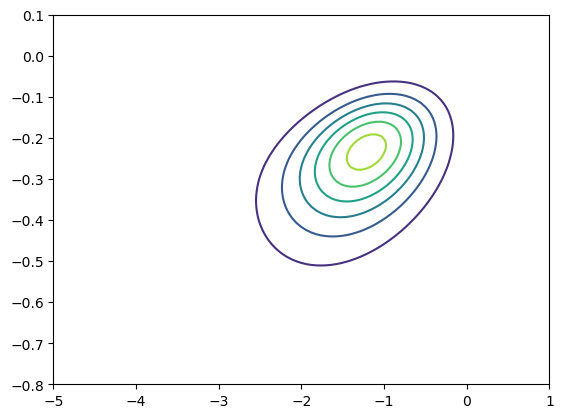

In [18]:
plot_contour(posterior_pmf.unstack())

In [19]:
joint_posterior = posterior_pmf.unstack()

In [20]:
marginal_inter = marginal(joint_posterior, 0)
marginal_slope = marginal(joint_posterior, 1)

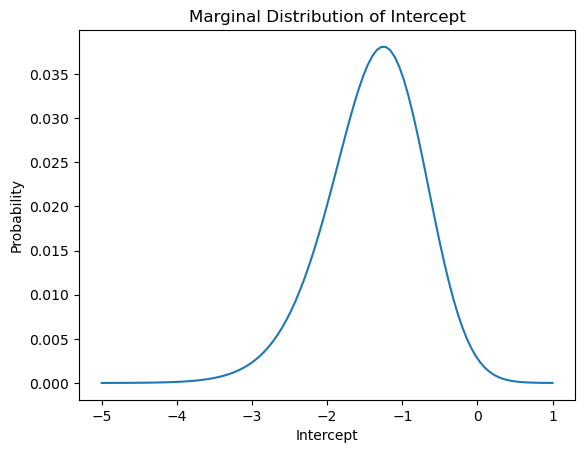

In [21]:
marginal_inter.plot()
plt.xlabel('Intercept')
plt.ylabel('Probability')
plt.title('Marginal Distribution of Intercept')
plt.show()

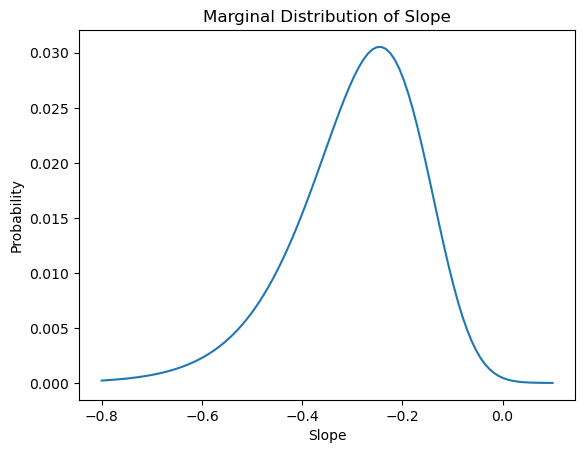

In [22]:
marginal_slope.plot()
plt.xlabel('Slope')
plt.ylabel('Probability')
plt.title('Marginal Distribution of Slope')
plt.show()  

In [23]:
def transform(pmf, func):
    """Transform the quantities in a PMF."""
    ps = pmf.ps
    qs = func(pmf.qs)
    return Pmf(ps, qs, copy=True)


In [24]:
marginal_probs = transform(marginal_inter, expit)

In [25]:
marginal_probs = marginal_inter.transform(expit)

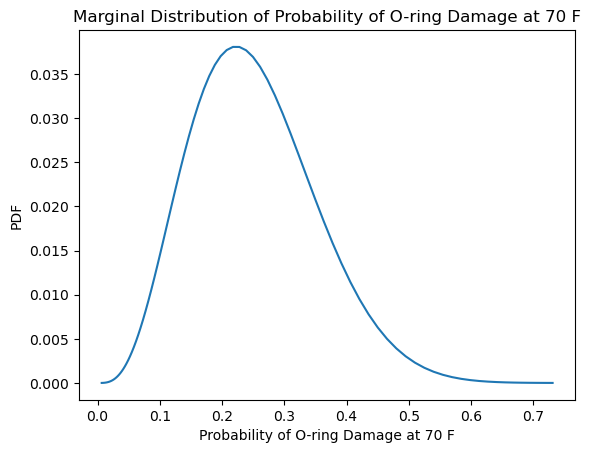

In [27]:
marginal_probs.plot()
plt.xlabel('Probability of O-ring Damage at 70 F')
plt.ylabel('PDF')
plt.title('Marginal Distribution of Probability of O-ring Damage at 70 F')
plt.show()